In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import numpy as np
import cv2 as cv
from PIL import Image
import os
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

cv.setNumThreads(0)

device='cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using: {device}")
print(torch.cuda.get_device_name(0))

Using: cuda
NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
BATCH_SIZE = 32
NUM_EPOCHS = 25
LEARNING_RATE = 0.001
IMG_SIZE = 224
NUM_CLASSES = 4

In [3]:
TRAIN_DIR="C:/Coding/ML_DL/Datasets/Training"
TEST_DIR="C:/Coding/ML_DL/Datasets/Testing"

In [4]:
class CustomDataset(Dataset):
    def __init__(self,data_dir,transform):
        self.data_dir=data_dir
        self.transform=transform
        self.images=[]
        self.labels=[]

        self.class_to_idx = {"glioma": 0, "meningioma": 1, "notumor": 2, "pituitary": 3}

        print("Scanning for images in class folders...")

        for class_name,class_idx in self.class_to_idx.items():
            class_dir=os.path.join(data_dir,class_name)

            class_images=0

            for image in os.listdir(class_dir):
                if image.endswith(('.jpeg', '.jpg', '.png')):
                    img_path=os.path.join(class_dir, image)
                    self.images.append(img_path)
                    self.labels.append(class_idx)
                    class_images+=1

        print(f"Total Images Loaded:{len(self.images)}")

    def __len__(self):
        return len(self.images)


    def mri_preprocessing(self,image):
        #contour cropping the tumour
        gray=cv.cvtColor(image,cv.COLOR_RGB2GRAY)
        gray=cv.GaussianBlur(gray,(5,5),0)
        thresh = cv.threshold(gray, 45, 255, cv.THRESH_BINARY)[1]
        cnts = cv.findContours(thresh.copy(), cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        cnts = cnts[0] if len(cnts) == 2 else cnts[1]

        if cnts:
            c=max(cnts,key=cv.contourArea)
            x, y, w, h = cv.boundingRect(c)
            image = image[y:y+h, x:x+w]

        #enhancing contrast
        gray_cropped = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
        clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        res = clahe.apply(gray_cropped)
        return cv.cvtColor(res, cv.COLOR_GRAY2RGB)

    def __getitem__(self, index):
        image_path=self.images[index]
        label=self.labels[index]

        image=cv.imread(image_path)

        if image is None:
            raise FileNotFoundError(f"Failed to load image at: {image_path}")

        image=cv.cvtColor(image,cv.COLOR_BGR2RGB)
        image = self.mri_preprocessing(image)
        image = Image.fromarray(image)

         
        if self.transform:
            image=self.transform(image)

        return image,label


Scanning for images in class folders...
Total Images Loaded:5712


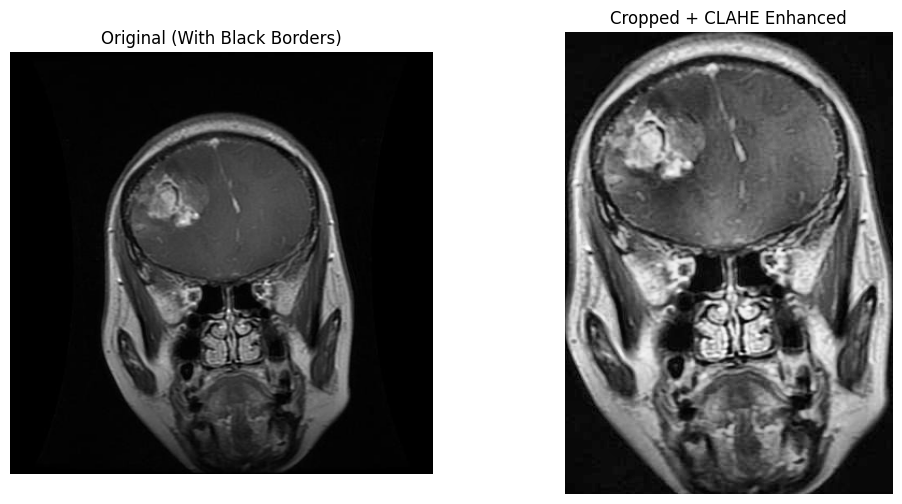

In [5]:

test_ds = CustomDataset(data_dir=TRAIN_DIR, transform=None)
raw_cv_img = cv.imread(test_ds.images[0])
raw_cv_img = cv.cvtColor(raw_cv_img, cv.COLOR_BGR2RGB)

# Process it
processed_img = test_ds.mri_preprocessing(raw_cv_img)

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(raw_cv_img)
plt.title("Original (With Black Borders)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(processed_img)
plt.title("Cropped + CLAHE Enhanced")
plt.axis('off')

plt.show()

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
train=CustomDataset(data_dir=TRAIN_DIR,transform=train_transforms)
test=CustomDataset(data_dir=TEST_DIR,transform=val_transforms)

train_size = int(0.8 * len(train))
val_size = len(train) - train_size


train_subset, val_subset = torch.utils.data.random_split(
        train,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

print(f"Training samples: {train_size}")
print(f"Validation samples: {val_size}")


Scanning for images in class folders...
Total Images Loaded:5712
Scanning for images in class folders...
Total Images Loaded:1311
Training samples: 4569
Validation samples: 1143


In [8]:
train_loader = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

print(f"Training batches per epoch: {len(train_loader)}")

val_loader = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

print(f"Validation batches per epoch: {len(val_loader)}")

test_loader = DataLoader(
        test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

print(f"Test batches: {len(test_loader)}")

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test)}")
print(f"Number of classes: {NUM_CLASSES}")


Training batches per epoch: 143
Validation batches per epoch: 36
Test batches: 41
Training samples: 4569
Validation samples: 1143
Test samples: 1311
Number of classes: 4


In [9]:
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BrainTumorCNN, self).__init__()

        # --- Feature Extraction Container ---
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
            nn.AdaptiveAvgPool2d((7, 7))
        )

        # --- Classifier Container ---
        self.classifier = nn.Sequential(
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # 1. Pass through feature extractor
        x = self.features(x)

        # 2. Flatten (Batch size, Channels * Height * Width)
        x = x.view(x.size(0), -1)

        # 3. Pass through classifier
        x = self.classifier(x)
        
        return x
    
model = BrainTumorCNN().to(device)

In [10]:
from torchsummary import summary

summary(model, (3, 128, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 256]             896
       BatchNorm2d-2         [-1, 32, 128, 256]              64
              ReLU-3         [-1, 32, 128, 256]               0
         MaxPool2d-4          [-1, 32, 64, 128]               0
           Dropout-5          [-1, 32, 64, 128]               0
            Conv2d-6          [-1, 64, 64, 128]          18,496
       BatchNorm2d-7          [-1, 64, 64, 128]             128
              ReLU-8          [-1, 64, 64, 128]               0
         MaxPool2d-9           [-1, 64, 32, 64]               0
          Dropout-10           [-1, 64, 32, 64]               0
           Conv2d-11          [-1, 128, 32, 64]          73,856
      BatchNorm2d-12          [-1, 128, 32, 64]             256
             ReLU-13          [-1, 128, 32, 64]               0
        MaxPool2d-14          [-1, 128,

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

sheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

In [12]:
def train_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    batch_num = 0
    for images, labels in tqdm(dataloader, desc="Training", leave=False):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        batch_num += 1
        if batch_num % 10 == 0:
            batch_acc = 100 * correct / total
            batch_loss = running_loss / total
            print(
                f"Batch {batch_num}/{len(dataloader)}, Loss: {batch_loss:.4f}, Acc: {batch_acc:.2f}%"
            )

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc


# validation


def validate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    print(f"Validation complete - {correct}/{total} samples correct")

    return epoch_loss, epoch_acc

In [13]:
training_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0

print("Starting Training")

for epoch in range(NUM_EPOCHS):

    current_lr = optimizer.param_groups[0]["lr"]
    print(f" Current learning rate: {current_lr:.6f}")

    print("TRAINING PHASE:")
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    print("VALIDATION PHASE:")
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    training_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print("EPOCH SUMMARY")
    print(f"Training - Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f"Validation - Loss: {val_loss:.4f} | Accuracy: {val_acc:.2f}%")

    if epoch > 0:
        train_loss_change = training_losses[-1] - training_losses[-2]
        val_acc_change = val_accs[-1] - val_accs[-2]
        print(f"Train Loss: {train_loss_change:+.4f} | Val Acc: {val_acc_change:+.2f}%")

        print("Updating learing rate")
        old_lr = optimizer.param_groups[0]["lr"]
        sheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]["lr"]

        if new_lr < old_lr:
            print(f"Learning rate reduced {old_lr:.6f} - {new_lr:.6f}")

        if val_acc > best_val_acc:
            improvement = val_acc - best_val_acc
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_brain_tumor_model.pth")

    print("TRAINING COMPLETED")
    print(f"Best Validation Accuracy: {best_val_acc}")

Starting Training
 Current learning rate: 0.001000
TRAINING PHASE:


Training:   7%|▋         | 10/143 [00:17<03:37,  1.63s/it]

Batch 10/143, Loss: 4.1079, Acc: 42.19%


Training:  14%|█▍        | 20/143 [00:30<02:00,  1.02it/s]

Batch 20/143, Loss: 3.5501, Acc: 43.28%


...

Batch 130/143, Loss: 0.2019, Acc: 91.83%


Training:  98%|█████████▊| 140/143 [00:32<00:00,  4.46it/s]

Batch 140/143, Loss: 0.2033, Acc: 91.72%


VALIDATION PHASE:


Validation complete - 1050/1143 samples correct
EPOCH SUMMARY
Training - Loss: 0.2029 | Accuracy: 91.73%
Validation - Loss: 0.2624 | Accuracy: 91.86%
Train Loss: -0.0082 | Val Acc: -1.05%
Updating learing rate
TRAINING COMPLETED
Best Validation Accuracy: 92.91338582677166


In [14]:
def evaluate_model(model, dataloader, device):

        print("Evaluating model on test set...")

        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in tqdm(dataloader, desc="Testing"):
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        print(f"Evaluated {len(all_labels)} test samples")
        return np.array(all_preds), np.array(all_labels)

print("Evaluating on test set")

test_preds, test_labels = evaluate_model(model, test_loader, device)

test_accuracy = 100 * np.sum(test_preds == test_labels) / len(test_labels)
print(f"Test Accuracy: {test_accuracy:.2f}%")

class_names = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

Evaluating on test set
Evaluating model on test set...


Testing: 100%|██████████| 41/41 [00:29<00:00,  1.40it/s]

Evaluated 1311 test samples
Test Accuracy: 89.86%
Classification Report:
              precision    recall  f1-score   support

      Glioma       0.89      0.81      0.85       300
  Meningioma       0.80      0.85      0.83       306
    No Tumor       0.96      0.96      0.96       405
   Pituitary       0.92      0.94      0.93       300

    accuracy                           0.90      1311
   macro avg       0.89      0.89      0.89      1311
weighted avg       0.90      0.90      0.90      1311



In [15]:
torch.save(model, "model.pth")